In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import geopandas as gpd

# Remote analysis of NDVI in Water Tracks on the North Slope, AK
1. Map watersheds with water tracks on the North Slope
2. Track-intertrack NDVI of water tracks on the North Slope

## 1. Map watersheds with water tracks on the North Slope
#### plot centroids of HYBAS level 10 watersheds, colored by typical and delayed green-up

load data
- lat, long = centroid of each watershed
- 'HYBAS_ID' = ID for level 10 watersheds from HydroATLAS
- 'pct_wts' = percentage area of a watershed that contains water tracks
- 'DGUP' = Delayed green-up, do water tracks in the watershed exhibit delayed green-up? 0 = no, 1 = yes

In [56]:
# load csv of north slope sheds
sheds = pd.read_csv('NS_sheds.csv')

In [57]:
# add column to color code sheds based on pct_wts and DGUP values
sheds['color'] = None 

for idx, row in sheds.iterrows():
    if row['pct_wts'] == 0.0:
        sheds.loc[idx, 'color'] = 'black'
    elif row['DGUP'] == 0:
        sheds.loc[idx, 'color'] = 'blue'
    else:
        sheds.loc[idx, 'color'] = 'red'

plot map

/local/scr/aekastning/TMPDIR/ipykernel_197729/947500303.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


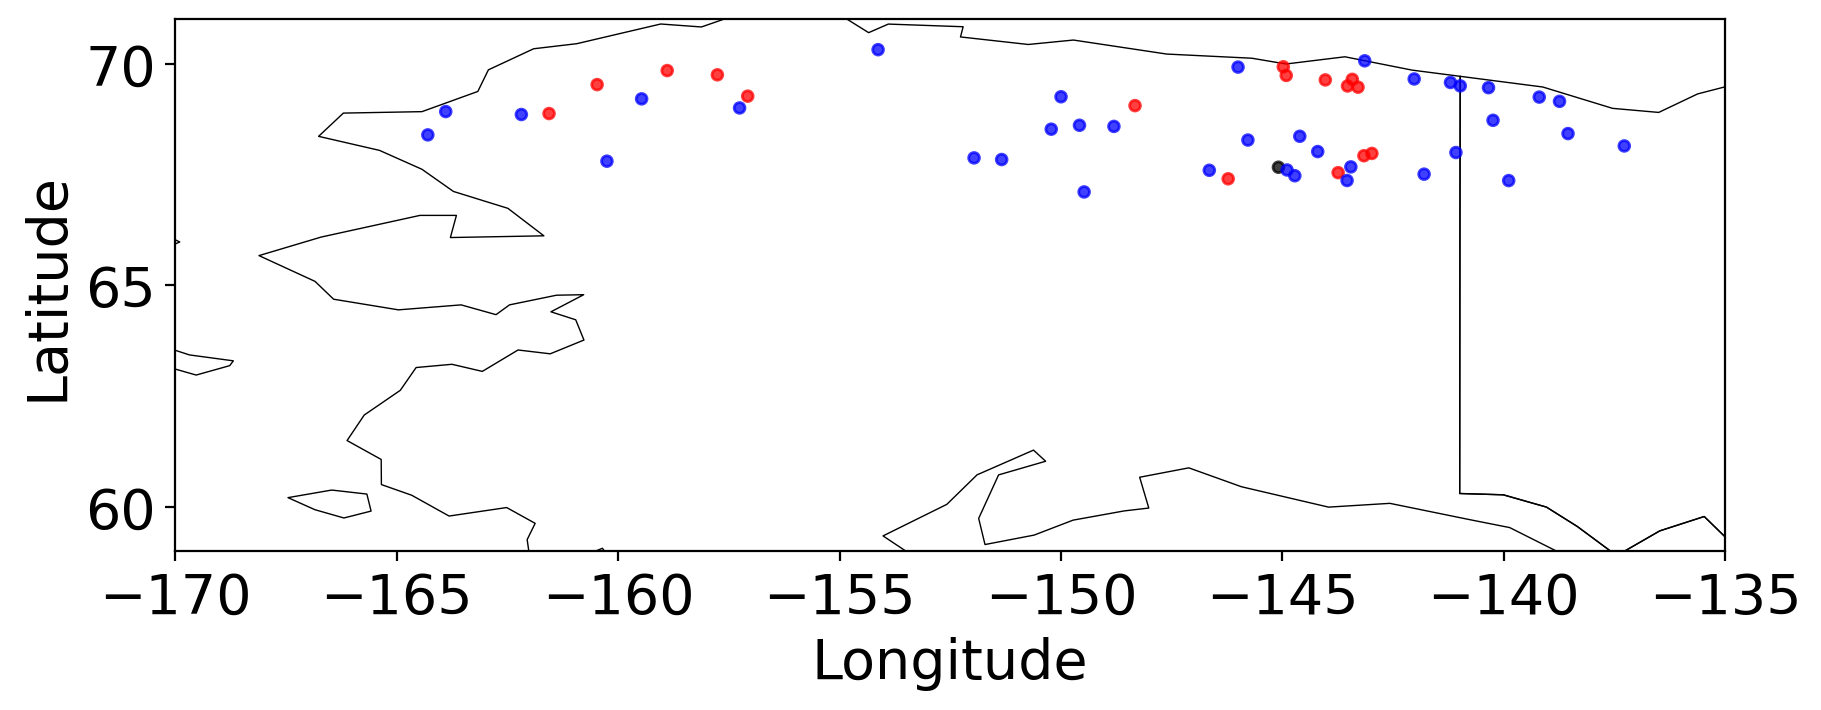

In [58]:
# load basemap
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

fig, ax = plt.subplots(figsize = (10,5), dpi = 200)

# plot basemap
world.boundary.plot(color = 'k', edgecolor='black', zorder = 0, ax=ax, linewidth = 0.5, label = '_nolegend_')

ax.scatter(
    sheds['long'],
    sheds['lat'],
    c=sheds['color'],
    alpha=0.75,
    s=15) # marker size

# ax.set_ylim(67,70.5)
# ax.set_xlim(-165, -136)
ax.set_ylim(59,71)
ax.set_xlim(-170, -135)
ax.tick_params(axis='both', which='major', labelsize=20)

ax.set_ylabel('Latitude', fontsize=20)
ax.set_xlabel('Longitude', fontsize=20)

# legend
# from matplotlib.lines import Line2D

# legend_elements = [
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Typical Green-up'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Delayed Green-up'),
#     Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='No Water Tracks'),
# ]
# ax.legend(handles = legend_elements, 
#           loc='center right', fontsize=14, bbox_to_anchor=(1.8, 0.5), frameon=False)

plt.show()

## 2. Track-intertrack NDVI of North Slope water tracks
#### in both typical and delayed green-up water tracks from 2019-2025

load data
- 'ndvi_mean_wt'= mean NDVI of pixels within water track AOI from Sentinel-2 (10-m) imagery
- 'ndvi_mean_it'= mean NDVI of pixels within intertrack AOI from Sentinel-2 from Sentinel-2 (10-m) imagery
- Date = Image date

run the following cells for each watershed: 8100087910 (delayed green-up), 8100130680 (typical green-up)

In [59]:
# ndvi = pd.read_csv('8100087910_ndvi_19-25.csv') #8100087910 (delayed green-up)
ndvi = pd.read_csv('8100130680_ndvi_19-25.csv') #8100130680 (typical green-up)

In [60]:
# convert to datetime, find day of year (doy) and year
ndvi['date'] = pd.to_datetime(ndvi['date'])
ndvi['doy'] = ndvi['date'].dt.dayofyear
ndvi['year'] = ndvi['date'].dt.year
# calculate ratio of water track to intertrack mean NDVI for each date
ndvi['ndvi_ratio'] = ndvi['ndvi_mean_wt'] / ndvi['ndvi_mean_it']

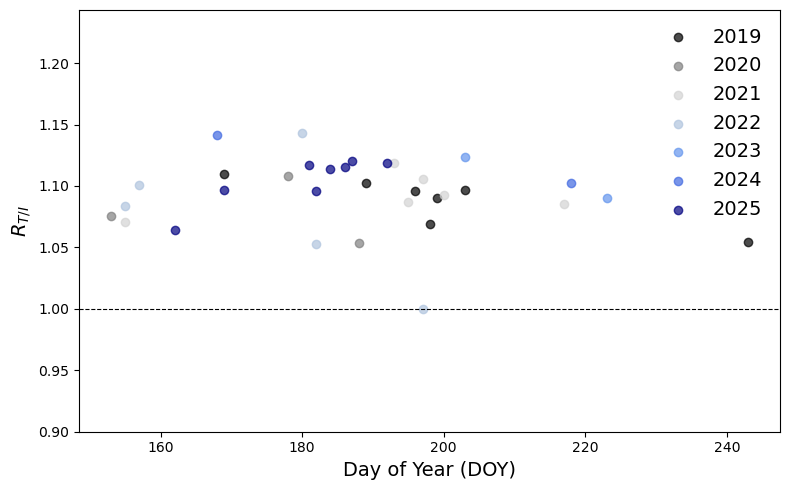

In [61]:
# plot
fig = plt.figure(figsize=(8, 5))

# list of each color per year
colors = {
    2019: 'black',
    2020: 'gray',
    2021: 'lightgray',
    2022: 'lightsteelblue',
    2023: 'cornflowerblue',
    2024: 'royalblue',
    2025: 'navy'
}


# plot data per year
for year, group in ndvi.groupby(by='year'):
    plt.scatter(group['doy'], group['ndvi_ratio'], label=year, color=colors[year], alpha=0.7)

# add dashed line where ndvi ratio = 1
plt.axhline(y=1, color='black', linestyle='--', linewidth=0.8)

# set y limits
ymin = np.nanmin(ndvi['ndvi_ratio'])
ymax = np.nanmax(ndvi['ndvi_ratio'])
plt.ylim((ymin-0.1), (ymax+0.1))

plt.xlabel('Day of Year (DOY)', fontsize = 14)
plt.ylabel(r'$R_{T/I}$', fontsize = 14)
plt.legend(frameon=False, fontsize=14)

plt.tight_layout()
plt.show()